<a href="https://colab.research.google.com/github/BluZky16/data-science-2026/blob/main/Pertemuan5/Pertemuan5_%5BRICHARDUS_EUGENE_TIJA%5D_%5B240401010214%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA: RICHARDUS EUGENE TIJA

NIM: 240401010214

Data Science

Kelas: IF403


In [ ]:
import pandas as pd

# Load the Titanic dataset from a public URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Display the first 5 rows to verify
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


/tmp/ipykernel_39175/1084295200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='viridis')


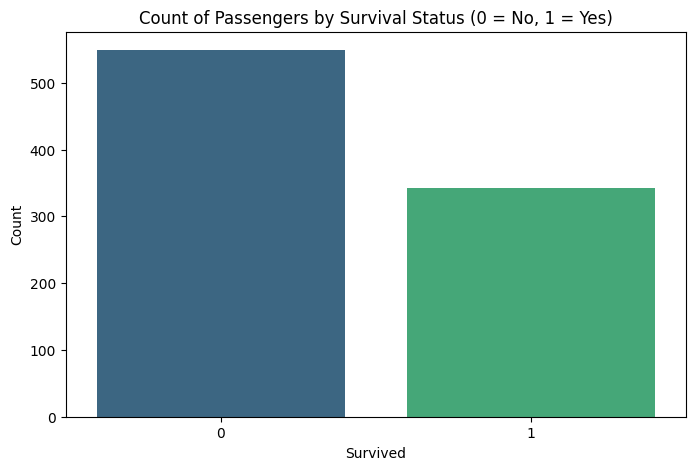

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar Chart: Survival Count
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Survived', palette='viridis')
plt.title('Count of Passengers by Survival Status (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

### Analisis: Jumlah Kelangsungan Hidup
**What?** Grafik batang ini menunjukkan bahwa jumlah penumpang yang meninggal jauh lebih banyak daripada yang selamat, dengan lebih dari 500 kematian dibandingkan dengan sekitar 340 penyintas. **So what?** Hal ini menyoroti tingginya tingkat kematian dalam tragedi Titanic, di mana sekitar 61% penumpang dalam dataset ini tidak selamat. **Now what?** Kita perlu menyelidiki faktor-faktor apa saja, seperti kelas penumpang atau jenis kelamin, yang berkontribusi pada peluang kelangsungan hidup yang lebih tinggi.

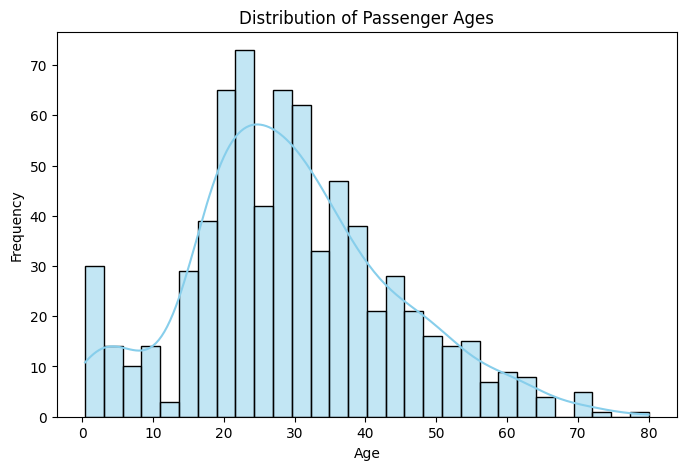

In [ ]:
# 2. Histogram: Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Analisis: Distribusi Usia
**What?** Histogram mengungkapkan bahwa sebagian besar penumpang berusia antara 20 hingga 40 tahun, dengan lonjakan yang terlihat pada bayi dan anak-anak di bawah usia 5 tahun. **So what?** Ini menunjukkan demografi yang muda di kapal, yang sangat penting untuk memahami efektivitas kebijakan evakuasi 'wanita dan anak-anak didahulukan'. **Now what?** Saya akan memeriksa apakah tingkat kelangsungan hidup untuk kelompok anak-anak secara signifikan lebih tinggi daripada mayoritas usia paruh baya.

/tmp/ipykernel_39175/2133435859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')


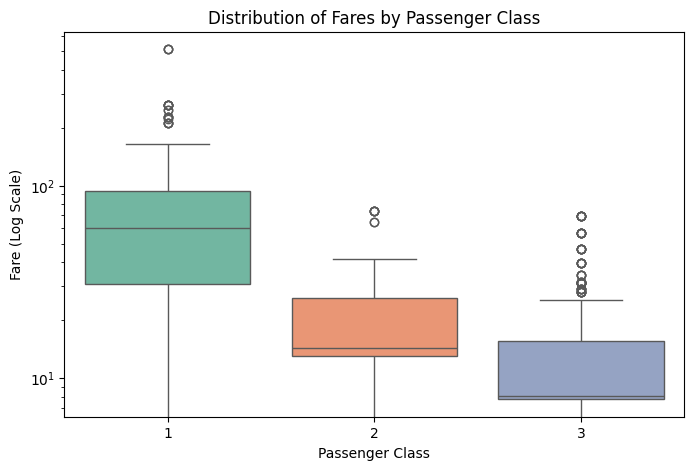

In [ ]:
# 3. Boxplot: Fare by Passenger Class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title('Distribution of Fares by Passenger Class')
plt.yscale('log') # Log scale to handle outliers
plt.xlabel('Passenger Class')
plt.ylabel('Fare (Log Scale)')
plt.show()

### Analisis: Tarif berdasarkan Kelas
**What?** Boxplot menampilkan distribusi tarif di berbagai kelas, menunjukkan bahwa penumpang kelas 1 membayar tarif yang jauh lebih tinggi, seringkali melebihi 100 unit, sementara tarif kelas 3 sebagian besar berada di bawah 20. **So what?** Terlihat kesenjangan ekonomi yang jelas, dan adanya outlier ekstrim di kelas 1 menunjukkan sekelompok kecil individu yang sangat kaya. **Now what?** Apakah tarif tinggi yang dibayarkan berkorelasi langsung dengan probabilitas kelangsungan hidup? Kita harus menguji korelasi antara Fare (tarif) dan Survived (selamat).

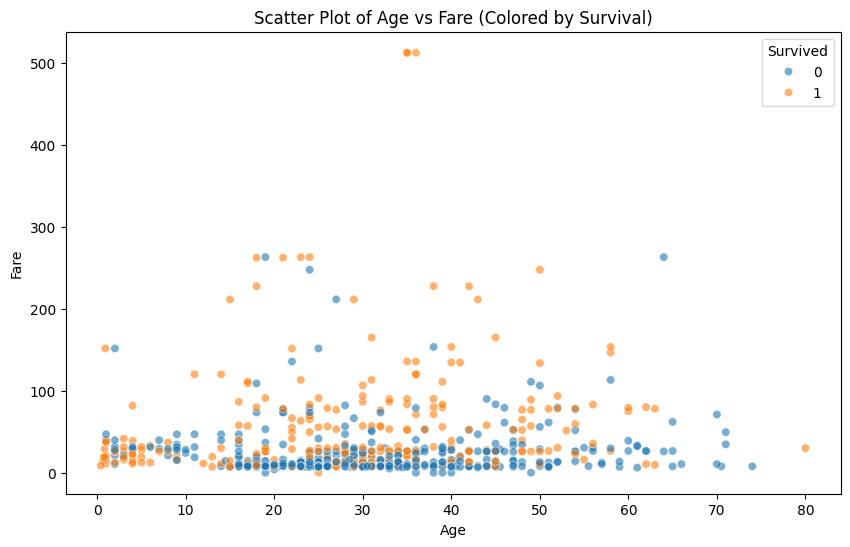

In [ ]:
# 4. Scatter Plot: Age vs Fare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.6)
plt.title('Scatter Plot of Age vs Fare (Colored by Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

### Analisis: Usia vs Tarif
**What?** Scatter plot ini menunjukkan tidak adanya korelasi linear yang kuat antara usia dan tarif, namun secara visual mengelompokkan penyintas (warna oranye) pada tingkat tarif yang lebih tinggi tanpa memandang usia. **So what?** Hal ini menunjukkan bahwa kekayaan (Tarif) merupakan prediktor kelangsungan hidup yang lebih kuat daripada kelompok usia tertentu untuk orang dewasa. **Now what?** Kita dapat melakukan analisis multivariat termasuk jenis kelamin untuk melihat apakah penyintas bertarif tinggi tersebut didominasi oleh perempuan.